_______
_______


# <center>Chapter 7: Partial Derivatives<br><sup><sup><br>The Python code was developed based on the R code written by <br> Samuel Shen, Distinguished Professor, San Diego State University, California, USA 
_______
_______

In [153]:
##### For first time Python users, these packages must be installed first
import numpy as np
import math
import pandas as pd
import statistics as stats
import scipy.stats as scistats
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import random
import sympy as sp
from matplotlib.colors import LinearSegmentedColormap

In [2]:
#Use same plot style as book for consistency
styledict = {'xtick.labelsize':12,
             'xtick.major.size':9,
             'xtick.major.width':1,
             'ytick.labelsize':12,
             'ytick.major.size':9,
             'ytick.major.width':1,
             'legend.framealpha':0.0,
             'legend.fontsize':15,
             'axes.labelsize':12,
             'axes.titlesize':14,
             'axes.linewidth':1,
             'figure.figsize':(8,8),
             'savefig.format':'jpg'}
plt.rcParams.update(**styledict)

## Symbolic Calculation of Partial Derivatives

In [3]:
#Create x, y variables as 'symbols'
x, y = sp.symbols('x, y')

#Define the function z = 2- x^2 - 2y^2 
## using symbols from above
z = 3 - x**2 - 2*y**2
z

-x**2 - 2*y**2 + 3

In [4]:
#Take derivative of z with respect to x
dz_dx = sp.diff(z, 'x')
dz_dx

-2*x

In [5]:
#Take derivative of z w.r.t y 
dz_dy = sp.diff(z, 'y')
dz_dy

-4*y

## Slope

In [6]:
#This is the slop of Ex 7.1
np.sin(1/2)*np.cos(1/2)*(np.sqrt(3)/2 + + 1/2)

0.574735370897548

In [7]:
#This is the x-directional slope
np.sin(1/2)*np.cos(1/2)

0.42073549240394825

In [8]:
x = 1/2
y = 1/2
np.sin(x)*np.cos(x)

0.42073549240394825

In [9]:
#Gradient directional slope
np.sqrt((np.cos(x)*np.sin(y))**2 + (np.sin(x)*np.cos(y))**2)

0.5950098395293859

## Fig 7.2: Surface and contours of z = f(x,y)

In [10]:
#Define function z(x,y)
z = lambda x, y: 3 - x**2 - 2*y**2 

In [11]:
#Define x and y domain 
x = y = np.linspace(-1,1,51)
#Create meshgrid over x,y
X, Y = np.meshgrid(x,y)

#Call function z on meshgrid
Z = z(X, Y)

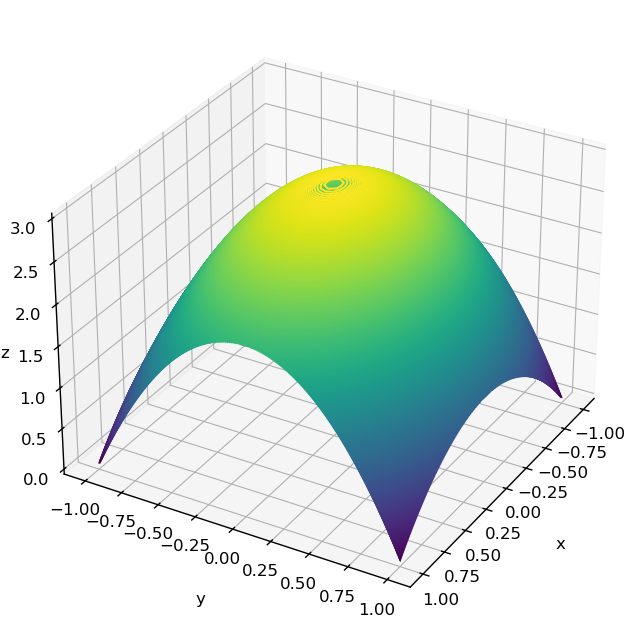

In [12]:
#Generate surface plot of Z
#Create 3D plot axes
ax = plt.axes(projection='3d')

#Create surface plot with 600 levels
surf = ax.contour3D(X, Y, Z, 600)
#Add labels to axes
ax.set_xlabel('x', labelpad = 15)
ax.set_ylabel('y', labelpad = 15)
ax.set_zlabel('z', labelpad = 1)

#Orient plot like in book
ax.view_init(30, 30)
plt.show()

## Fig 7.2(a): Contours

In [14]:
#Define specified color map used in book
mycmap = LinearSegmentedColormap.from_list("mycmap", 
        ["blue", "limegreen", "yellow", "orange", "red"])

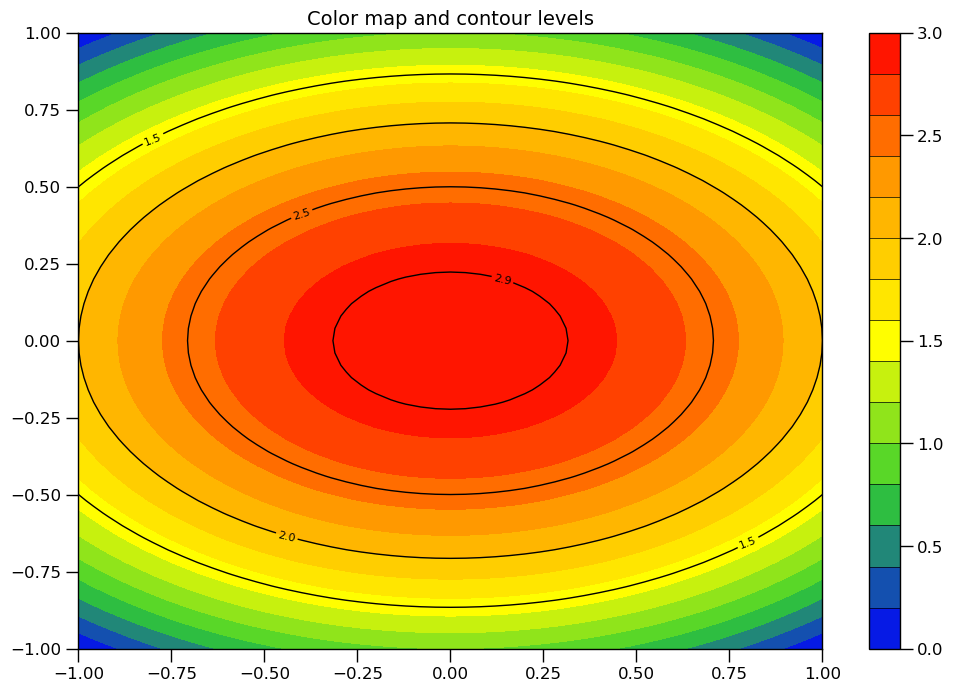

In [15]:
#Contour map of surface plot in 7.2
fig, ax = plt.subplots(figsize=(12,8))
#Plot filled contour map, use specified color map
CS = ax.contourf(X, Y, Z, levels=15,
                cmap=mycmap)
#Plot the contour lines at 1.5, 2, 2.5 and 2.9
CSl = ax.contour(X, Y, Z, levels=[1.5, 2., 2.5, 2.9],
                 colors='k', linewidths=1)
#Add labels to our lines
ax.clabel(CSl, CSl.levels, fontsize=8, colors='k')
#Add color bar to figure
plt.colorbar(CS, ticks=np.arange(0,3.1,0.5), drawedges=True)
#Add title
ax.set_title('Color map and contour levels')
plt.show()

## Fig 7.3: Contours and Directions

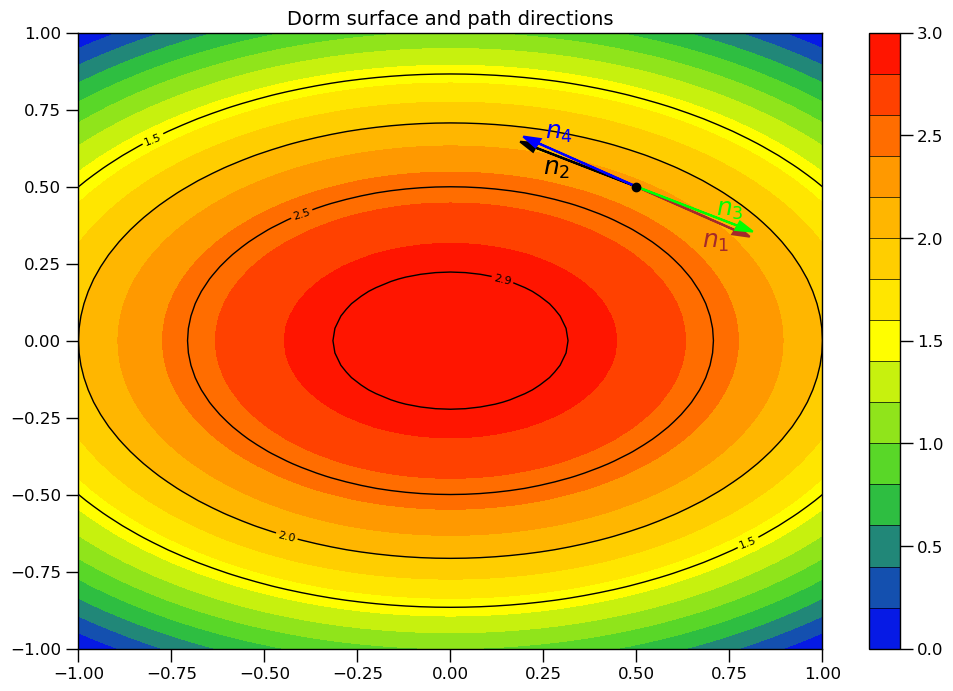

In [49]:
#Adding path direction arrows onto contour graph above
#Code from Fig 7.2(a)
fig, ax = plt.subplots(figsize=(12,8))
#Plot filled contour map, use specified color map
CS = ax.contourf(X, Y, Z, levels=15,
                cmap=mycmap)
#Plot the contour lines at 1.5, 2, 2.5 and 2.9
CSl = ax.contour(X, Y, Z, levels=[1.5, 2., 2.5, 2.9],
                 colors='k', linewidths=1)
#Add labels to our lines
ax.clabel(CSl, CSl.levels, fontsize=8, colors='k')
#Add color bar to figure
plt.colorbar(CS, ticks=np.arange(0,3.1,0.5), 
             drawedges=True)

#Adding arrows
#n_1
ax.arrow(0.5, 0.5, 0.8821*0.3, -0.4711*0.3, 
        head_width = 0.03, color = 'brown', linewidth = 1.5)
ax.text(0.5 + 0.8821*0.3/1.5, 0.43 - 0.4231*0.3, 
         r'$n_1$', size = 18, color = 'brown')

#n_2
ax.arrow(0.5,0.5,-0.90611*0.3,0.4231*0.3, 
          head_width = 0.03, color = 'black', linewidth = 1.5)
ax.text(0.52-0.90611*0.3,0.415+0.4231*0.3, 
         r'$n_2$', size = 18)

#n_3
ax.arrow(0.5,0.5,0.9061*0.3,-0.4231*0.3, 
        head_width = 0.03, color = 'lime', linewidth = 1.5)
ax.text(0.45+0.8821*0.3,0.55-0.4711*0.3, 
         r'$n_3$', size = 18, color = 'lime')

#n_4
ax.arrow(0.5,0.5,-0.8821*0.3,0.4711*0.3, 
        head_width = 0.03,color = 'b', linewidth = 1.5)
ax.text(0.52-0.8821*0.3,0.515+0.4711*0.3, 
         r'$n_4$', size = 18, color = 'b')

#Central point
ax.scatter(0.5, 0.5, color='k')

#Add title
ax.set_title('Dorm surface and path directions')
plt.show()

## Fig 7.4: Travelling wave w = f(x - ct)

In [55]:
#Define function w(x,t)
w = lambda x, t: 0.3*np.sin(x - 10*t)

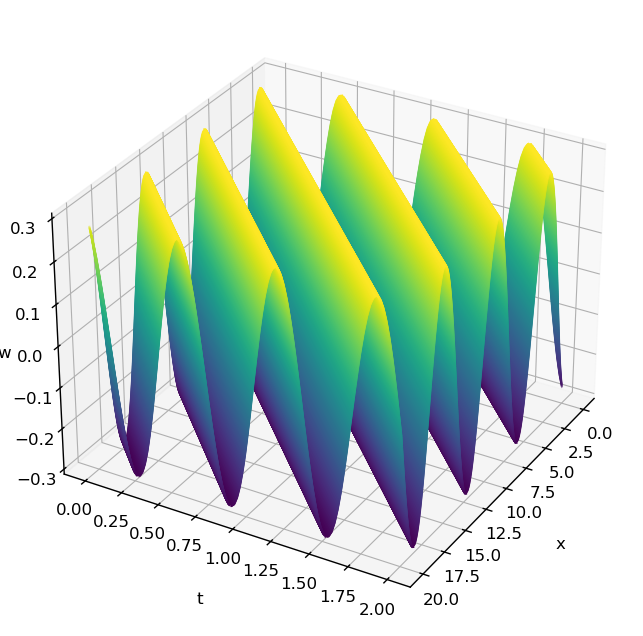

In [57]:
x = np.linspace(0, 20, 201)
t = np.linspace(0, 2, 101)
X, T = np.meshgrid(x, t)
W = fct(X,T)

#Generate surface plot of Z
#Create 3D plot axes
ax = plt.axes(projection='3d')

#Create surface plot with 600 levels
surf = ax.contour3D(X, T, W, 600)
#Add labels to axes
ax.set_xlabel('x', labelpad = 15)
ax.set_ylabel('t', labelpad = 15)
ax.set_zlabel('w', labelpad = 1)

#Orient plot like in book
ax.view_init(30, 30)
plt.show()

## Fig 7.4(b): Contours

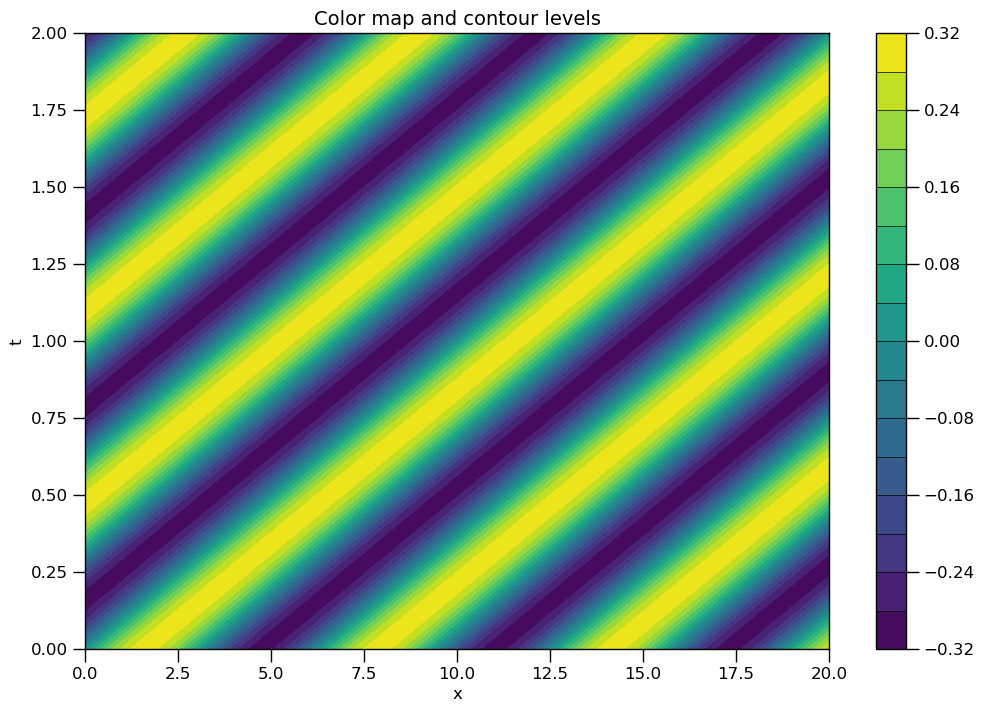

In [62]:
#Contour map of surface plot in 7.4
fig, ax = plt.subplots(figsize=(12,8))

#Plot filled contour map, use specified color map
CS = ax.contourf(X, T, W, levels=15)
#Add color bar
plt.colorbar(CS, drawedges=True)
#Add title
ax.set_title('Color map and contour levels')
#Add axes labels
ax.set_xlabel('x')
ax.set_ylabel('t')
plt.show()

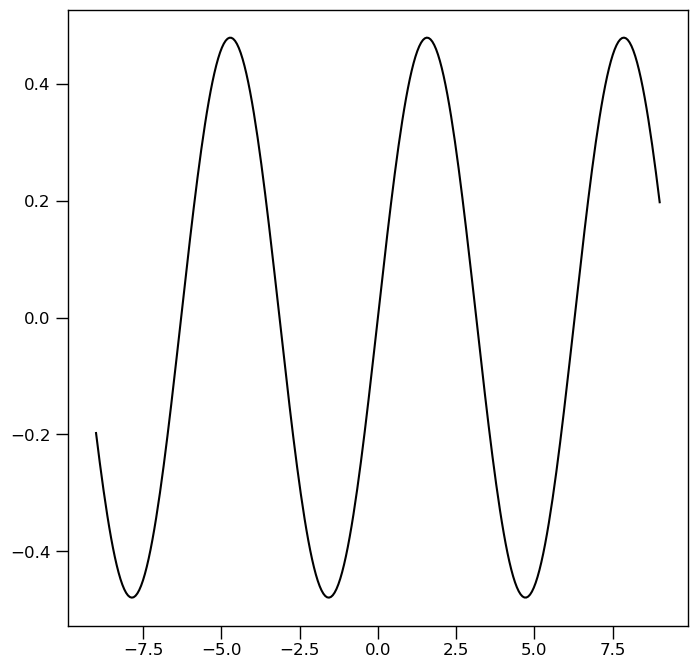

In [66]:
#Standing wave
x = np.linspace(-9, 9, 301)
t = 0.5
y = np.sin(t)*np.sin(x)
plt.plot(x, y, 'k')
plt.show()

## Fig 7.5(a): Copper, Large D and fast diffusion

In [67]:
#Define temperature function
temp = lambda x, t: 500*(D*t)**(-1/2)*np.exp(-x**2/(4*D*t))

In [94]:
#Define parameters
D = 111
x = np.linspace(-8, 8, 401)
t = np.linspace(0.01, 1, 200)
X, T = np.meshgrid(x,t)

#Generate temperatures
c_temp = temp(X,T)

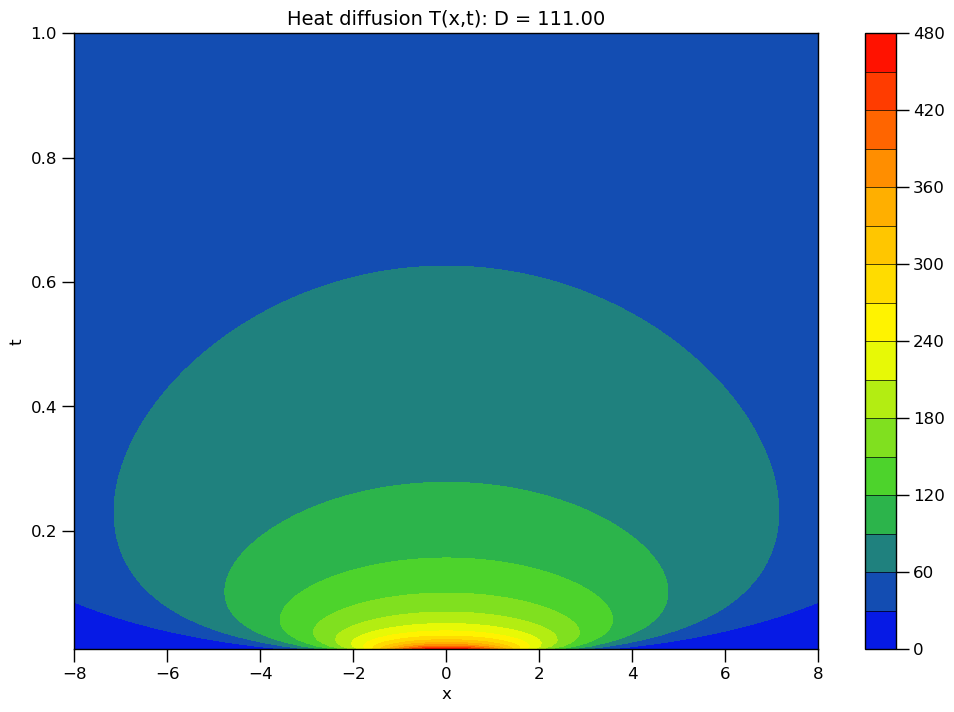

In [95]:
#Create contour plot for Temp
fig, ax = plt.subplots(figsize=(12,8))

#Plot filled contour map, use specified color map
CS = ax.contourf(X, T, c_temp, levels=15, 
                cmap=mycmap)
#Add color bar
plt.colorbar(CS, drawedges=True)
#Add title
ax.set_title('Heat diffusion T(x,t): D = 111.00')
#Add axes labels
ax.set_xlabel('x')
ax.set_ylabel('t')
plt.show()

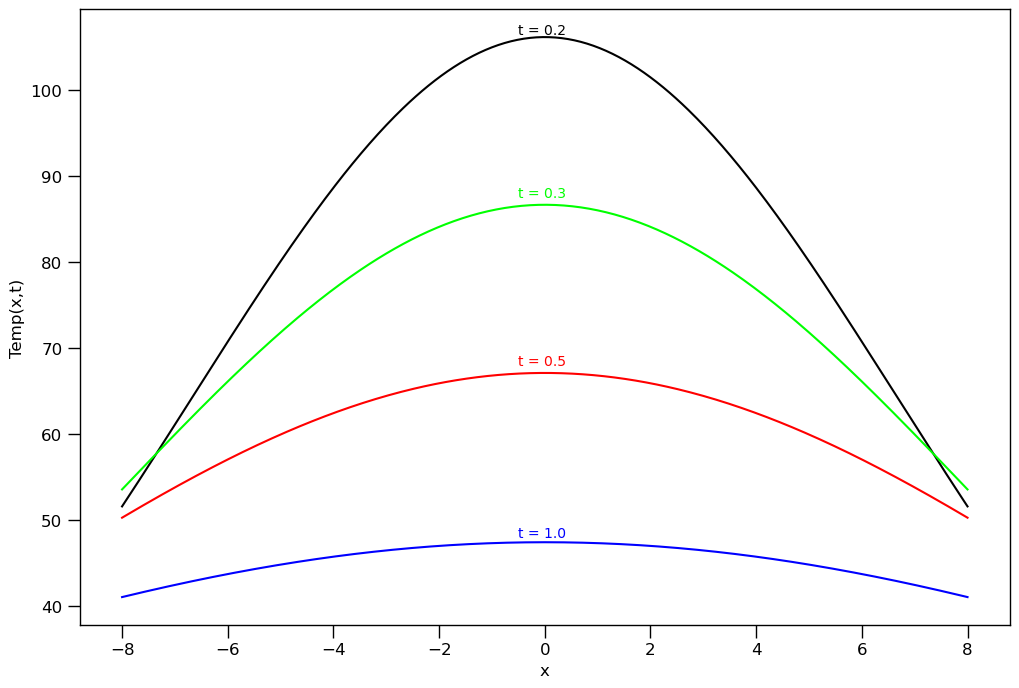

In [90]:
#Plot temperature at different values of t on same plot
#Different values of t
ts = [0.2, 0.3, 0.5, 1.]
#Corresponding colors
cols = ['black', 'lime', 'red', 'blue']
#Location to annotate time
yvals = [106.5, 87.5, 68, 48]

#Plot temps
fig, ax = plt.subplots(figsize=(12,8))
for i in range(4):
    ax.plot(x, temp(x, ts[i]), color=cols[i])
    ax.text(-0.5, yvals[i], f't = {ts[i]}',
           color=cols[i])

ax.set_xlabel('x')
ax.set_ylabel('Temp(x,t)')

plt.show()

## Fig 7.5(b): Steel, small D and slow diffusion

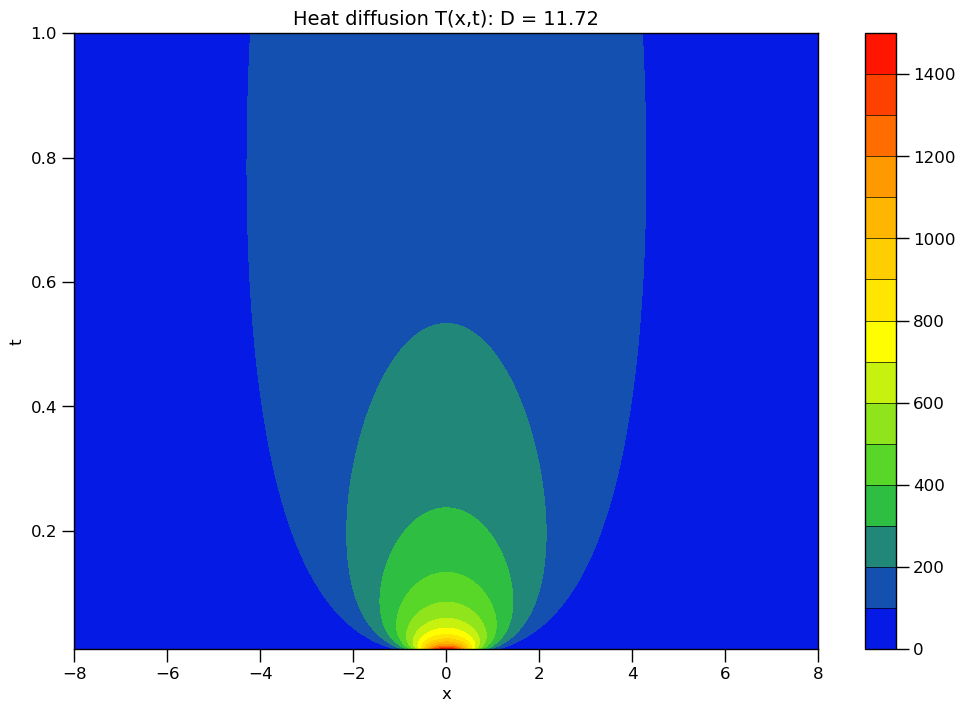

In [97]:
#Using same function and parameters as above, but changing D
#Define parameters
D = 11.72
x = np.linspace(-8, 8, 401)
t = np.linspace(0.01, 1, 200)
X, T = np.meshgrid(x,t)

s_temp = temp(X, T)

#Create contour plot for Temp
fig, ax = plt.subplots(figsize=(12,8))

#Plot filled contour map, use specified color map
CS = ax.contourf(X, T, s_temp, levels=15, 
                cmap=mycmap)
#Add color bar
plt.colorbar(CS, drawedges=True)
#Add title
ax.set_title('Heat diffusion T(x,t): D = 11.72')
#Add axes labels
ax.set_xlabel('x')
ax.set_ylabel('t')
plt.show()

In [105]:
#Spatial distribution of temp for a given time
#Different values of t
x = np.linspace(-8,8,401)
ts = np.array([0.1, 0.2, 0.5])
D = 20

#Compute temperature for each value of t
temps = [temp(x, t) for t in ts]

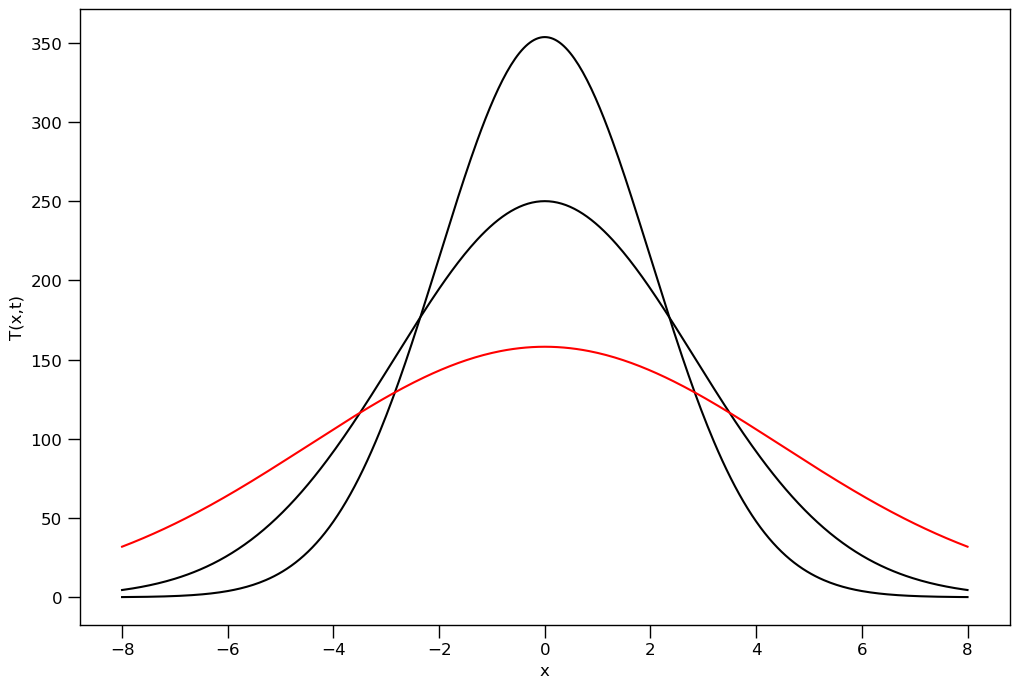

In [109]:
#Generate plot to visualize data
#Plot temps
fig, ax = plt.subplots(figsize=(12,8))
for i in range(3):
    #Plot each value, color t=0.5 as red
    ax.plot(x, temps[i], 'r' if i==2 else 'k')
    
ax.set_xlabel('x')
ax.set_ylabel('T(x,t)')

plt.show()

## Earth's gravitational acceleration

In [111]:
G = 6.67430*10**(-11) #Units: m^3/(kg*sec)
M = 5.972*10**(24) #mass of earth in kg
r = 6371*10**3 #radius of earth in meters
potential = G*M/r
potential 

62563050.69847748

In [112]:
# GMm/r = m(GM/r) = mv^2 kinetic energy
# GMm/r^2 is the gravitational force 
# Forve/mass = acceleation: 
# (GMm/r^2)/m = G*M/r^2 is the gravitational acceleration
-G*M/r**2

-9.819973426224687

This value is what we are familiar with seeing as the graviational constant 'g'

## Gravitational force on a human body

In [113]:
G = 6.67430*10**(-11)
M = 5.972*10**(24) #mass of earth in kg
r = 6371*10**3 #radius of earth in meters
m = 70 #kg
-G*M*m/r**2

-687.398139835728

In [114]:
G = 6.67430*10**(-11)
M = 70  #your mass in kg
m = 40 #your brother mass in kg
r = 1 #1 meter away
-G*M*m/r**2

-1.8688039999999999e-07

## Gravitational force on an inch of hair

In [115]:
w = 0.00064 #[ounces]
wkg = 0.00064 * 28.34/1000 #ounces to kg
wkg

1.81376e-05

In [116]:
#1.8X10^(-4) Newton
#1,000 times more than the force 
#between two human bodies
hair_gravity_force = wkg * 9.8
hair_gravity_force

0.00017774848

## Potential energy: $U = mgh$ when $h = 2$

In [118]:
#Derivation
G = 6.67430*10**(-11) #Units: m^3/(kg*sec)
M = 5.972*10**(24) #mass of earth in kg
r = 6371*10**3 #radius of earth in meters
m = 1 #kg. This is the mass of a object whose 
#potential energy is to be computed. Notation 
#m0 may be used here to make a difference from unit m: meter. 

h = 2 #meters. This is a height of the object of mass m0
p1 = -G*M*m/(r + h) ##Units m^3/(kg*sec) * kg /m = m^2/s^2 
#potential energy at height h from Earth's surface
#with respect to the center of Earth

p0 = -G*M*m/(r + 0) #potential at the Earth's surface: h =0
p1

-62563031.05853679

In [119]:
p0

-62563050.69847748

In [121]:
Dp = p1 - p0 #potential energy as the difference of potentials
Dp #difference of the potential w.r.t. to the Earth center

19.639940686523914

In [122]:
g = 9.8 #m/s^2
Ep = m*g*h #potential energy computed from Ep = m0 gh
Ep #or Ep = mgh when we use m to replace m0

19.6

In [125]:
#The math approximation is based on the formula:
# (-1/(r+h))- (-1/r) approximately equal h/r^2
#Thus GMm[(-1/(r+h))- (-1/r)] \approx GMmh/r^2
# =(GM/r^2) mh = g  mh = mgh
#because G*M/r^2 = 9.8 meter/s^2

Ep/Dp  #mgh potential energy divided by the potential diff

0.9979663540149427

## Potential energy: $U = mgh$ when $h = 200,000$ meters

In [129]:
#Derivation
G = 6.67430*10**(-11) #Units: m^3/(kg*sec)
M = 5.972*10**(24) #mass of earth in kg
r = 6371*10**3 #radius of earth in meters
m = 1 #kg

h = 200000 #meters. This is a height of the object of mass m0
p1 = -G*M*m/(r + h) ##Units m^3/(kg*sec) * kg /m = m^2/s^2 

p0 = -G*M*m/(r + 0) #potential at the Earth's surface: h =0
p1

-60658833.66306498

In [130]:
p0

-62563050.69847748

In [131]:
#Difference of potential as calculated above
Dp =p1 - p0 #potential energy as the difference of potentials
Dp 

1904217.0354124978

In [132]:
g = 9.8 #m/s^2
Ep = m*g*h #potential energy computed from Ep = m0 gh
Ep #or Ep = mgh when we use m to replace m0

1960000.0000000002

In [133]:
Ep/Dp

1.0292944362696652

In [134]:
100*(Ep - Dp)/Dp #If h = 2000 km, the error is about 31%. 

2.9294436269665303

## Vector field, source, and sink

In [144]:
#Define circular function
f = lambda x, y: x**2 + y**2

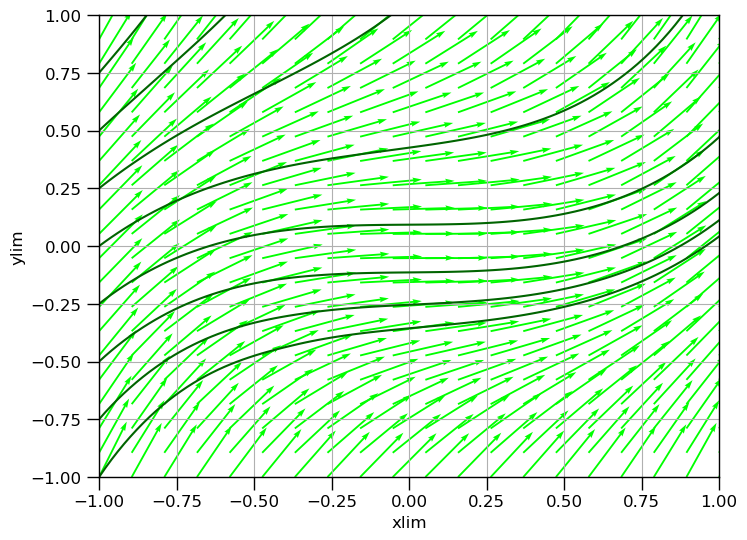

In [165]:
#Define fucntoin
def f(t, y):
    x, y_val = y
    dxdt = x**2 + y_val**2
    dydt = 1  # moving forward uniformly in 'y' direction (similar to time)
    return [dxdt, dydt]

#Define the grid
x = np.linspace(-1, 1, 20)
y = np.linspace(-1, 1, 20)
X, Y = np.meshgrid(x, y)

#Compute vector components
U = X**2 + Y**2
V = np.ones_like(U)

#Normalize arrows for better visibility
N = np.sqrt(U**2 + V**2)
U2, V2 = U/N, V/N

#Plot vector field
plt.figure(figsize=(8, 6))
plt.quiver(Y, X, V2, U2, scale=10, color='lime')

#Solve ODE from different starting x-positions
for xs in np.arange(-1, 1.25, 0.25):
    sol = solve_ivp(f, t_span=[-1, 1], y0=[xs, -1], t_eval=np.linspace(-1, 1, 100))
    plt.plot(sol.y[1], sol.y[0], color='darkgreen')

plt.xlim(-1., 1.)
plt.ylim(-1., 1.)
plt.xlabel('xlim')
plt.ylabel('ylim')
plt.grid(True)
plt.show()

## Fig 7.8(a): Source

In [176]:
#Define parameters
m = 4
n = 20
r = [0.2, 0.4, 0.8, 1.5]

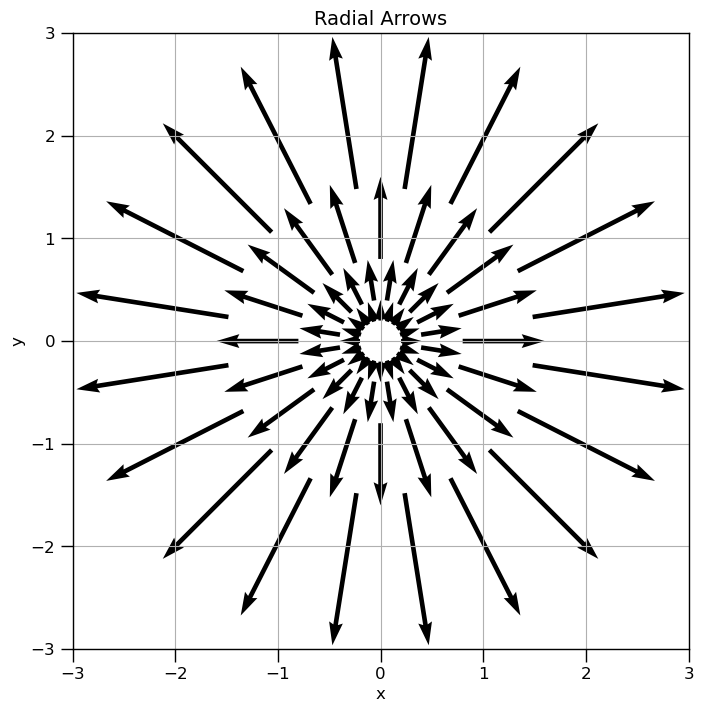

In [184]:
fig, ax = plt.subplots()
for i in range(m):
    #Create five arrays that range from 1:20
    th = np.zeros(n)
    x = np.zeros(n)
    y = np.zeros(n)
    u = np.zeros(n)
    v = np.zeros(n)
    for j in range(n):
        th[j] = j*2*np.pi/n + i*np.pi/n
        x[j] = r[i]*np.cos(th[j])
        y[j] = r[i]*np.sin(th[j])
        u[j] = x[j]
        v[j] = y[j]
    ax.quiver(x, y, u, v, angles='xy', scale_units='xy', scale=1)
    
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Radial Arrows')
plt.grid(True)
plt.show()